## 1. Data Preperation

### a) Compile Data

In [1]:
import pandas as pd

The data is stored in an excel file, with multiple sheets and extra rows. To select the rows we want, we must choose the correct sheet and skip irrelevant metadata rows.

In [2]:
# read unemployment data, select correct sheet, skip metadata rows
unemployment_data = pd.read_excel('6202006.xlsx', sheet_name = 'Data1', skiprows=9)

# read inflation data, select correct sheet, skip metadata rows
inflation_data = pd.read_excel('640101.xlsx', sheet_name = 'Data1', skiprows=9)

# read interest rate data, select correct sheet, skip metadata rows
interest_rates_data = pd.read_excel('f01d.xlsx', sheet_name = 'Data', skiprows=10)

After reading the Excel files, the respective columns are selected. Because of the way it is formatted, the Series ID ends up being the header for the dates. Thus both selected columns will be renamed appropriately. 

In [3]:
# select relevant columns
unemployment_data = unemployment_data[["Series ID", "A84423620T"]]
inflation_data = inflation_data[["Series ID", "A2325846C"]]
interest_rates_data = interest_rates_data[["Series ID", "FIRMMCRTD"]]

# show first 5 rows
unemployment_data.head(5)

,Series ID,A84423620T
0,1978-02-01,8.441453
1,1978-03-01,7.860293
2,1978-04-01,7.034785
3,1978-05-01,7.102146
4,1978-06-01,7.125177


In [4]:
# rename inflation data columns appropriately
unemployment_data = unemployment_data.rename(columns={"A84423620T": "Unemployment", "Series ID": "Date"})
inflation_data = inflation_data.rename(columns={"A2325846C": "Inflation", "Series ID": "Date"})
interest_rates_data = interest_rates_data.rename(columns={"FIRMMCRTD": "Interest Rate", "Series ID": "Date"})

The date on all the excel files are then converted to datetime format and filtered to only include data from 2011-01-01 to 2024-12-31.

In [5]:
# change to standardised datetime format 
unemployment_data["Date"] = pd.to_datetime(unemployment_data["Date"])
inflation_data["Date"] = pd.to_datetime(inflation_data["Date"])
interest_rates_data["Date"] = pd.to_datetime(interest_rates_data["Date"])

In [6]:
# filter dates from 2011-01-01 to 2024-12-31
low = '2011-01-01'
high = '2024-12-31'

unemployment_data = unemployment_data[(unemployment_data["Date"] >= low) & (unemployment_data["Date"] <= high)]
inflation_data = inflation_data[(inflation_data["Date"] >= low) & (inflation_data["Date"] <= high)]
interest_rates_data = interest_rates_data[(interest_rates_data["Date"] >= low) & (interest_rates_data["Date"] <= high)]

An index is set up for the 'Date' coloumn on each file which will then be joined in one dataset based on date. 

In [7]:
# Set index for join
unemployment_data = unemployment_data.set_index("Date")
inflation_data = inflation_data.set_index("Date")
interest_rates_data = interest_rates_data.set_index("Date")

In [8]:
# Join datasets
master_data = unemployment_data.join(inflation_data, how="outer").join(interest_rates_data, how="outer")

### b) Fix Interest Rate Data

The date between the data set has some discreprencies, where interest rate data is sorted by day. However, unemployment data and inflation data is sorted by month. This creates many gaps in the data set as shown below:

In [9]:
master_data.isna().sum()

Unemployment     3433
Inflation        3545
Interest Rate      59
dtype: int64

To fix this, we will only take the last available data for each month to eliminate gaps in the dataset. 

In [10]:
# Take last available data for each month
master_data = master_data.resample("ME").last()

In [11]:
# Sort by date
master_data = master_data.sort_index()

Now, we are left with monthly data as depicted below:

In [12]:
master_data.head(10)

,Unemployment,Inflation,Interest Rate
Date,,,
2011-01-31,6.096681,NaN,4.75
2011-02-28,6.500871,NaN,4.75
2011-03-31,6.091718,98.3,4.75
2011-04-30,5.247593,NaN,4.75
2011-05-31,5.273783,NaN,4.75
2011-06-30,5.051848,99.2,4.75
2011-07-31,5.161525,NaN,4.75
2011-08-31,5.736065,NaN,4.75
2011-09-30,5.195414,99.8,4.75


## 2. Exploratory Data Analysis (EDA)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

Before EDA is conducted, we must clean the data and resolve missing values. Since inflation is recorded quarterly, there will be gaps in the months where quarterly data is not recorded. This can be determined by intertpolating missing values which will smooth out results. 

In [14]:
#check missing values
master_data.isna().sum()

Unemployment       0
Inflation        112
Interest Rate      0
dtype: int64

In [15]:
# interpolate missing values
master_data = master_data.interpolate(method="linear")

# fill missing values that cannot be interpolated with the value of the previous tuple
master_data["Inflation"] = master_data["Inflation"].bfill()

In [16]:
#check missing values
master_data.isna().sum()

Unemployment     0
Inflation        0
Interest Rate    0
dtype: int64

In [17]:
# show top 10 rows
master_data.head(10)

,Unemployment,Inflation,Interest Rate
Date,,,
2011-01-31,6.096681,98.3,4.75
2011-02-28,6.500871,98.3,4.75
2011-03-31,6.091718,98.3,4.75
2011-04-30,5.247593,98.6,4.75
2011-05-31,5.273783,98.9,4.75
2011-06-30,5.051848,99.2,4.75
2011-07-31,5.161525,99.4,4.75
2011-08-31,5.736065,99.6,4.75
2011-09-30,5.195414,99.8,4.75


First, univariate analysis will be conducted on unemployment rate, inflation, and interest rate to analyse general trends individually. 

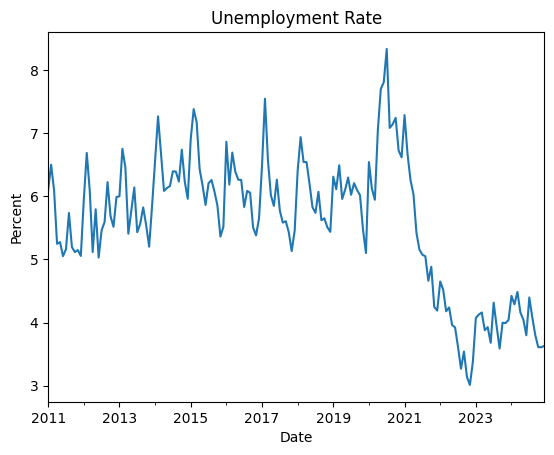

In [18]:
master_data['Unemployment'].plot(title="Unemployment Rate")
plt.ylabel("Percent")
plt.show()

Before 2020, unemployment rate stayed fairly consistent at roughly a 5% - 7.5% range. In 2020, a large spike in unemployment rate can be seen, reaching over 8%. A sharp decline in unemployment rate follows from 2021 to 2023, settling around 4% in 2024-2025. 

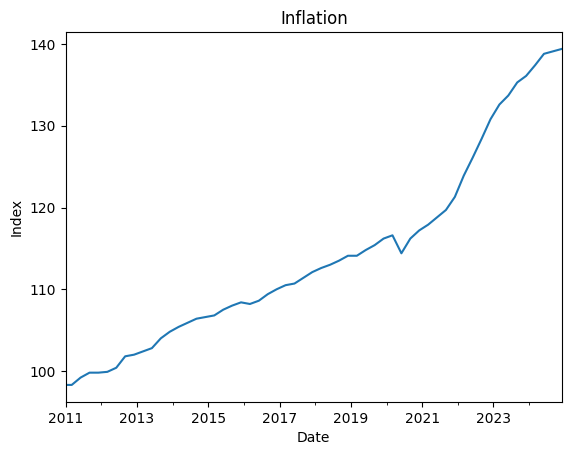

In [19]:
master_data['Inflation'].plot(title="Inflation")
plt.ylabel("Index")
plt.show()

The inflation rate can be seen as generally trending upwards. In 2020 there was a slight drop in inflation rate, which then rebounded and continued to trend upwards. It can also be noted that after the slight drop, the slope of the inflation rate is steeper, meaning had climbed faster compared to before 2020. 

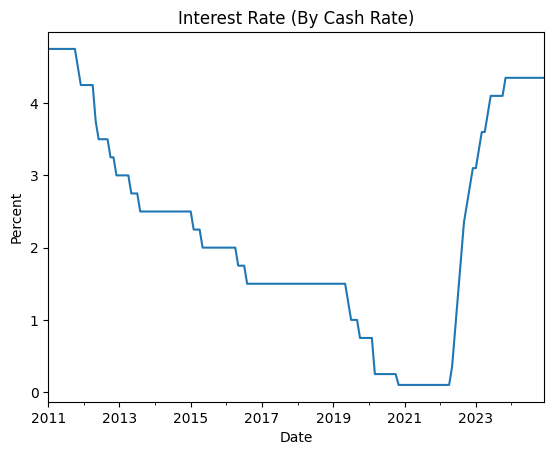

In [20]:
master_data['Interest Rate'].plot(title="Interest Rate (By Cash Rate)")
plt.ylabel("Percent")
plt.show()

From 2011 to 2021, the interest rate has been gradually declining from roughly 4.8% to 0.3%. In 2022, there was a sharp jump in interest rates which had settled in 2023 at aroung 4.2%.

Now, unemployment rate, inflation and interest rate will be plotted against each other to observe trends between the groups. Since inflation uses an index instead of a percentage, normalising the data first will better visualise the trends relative to each other. 

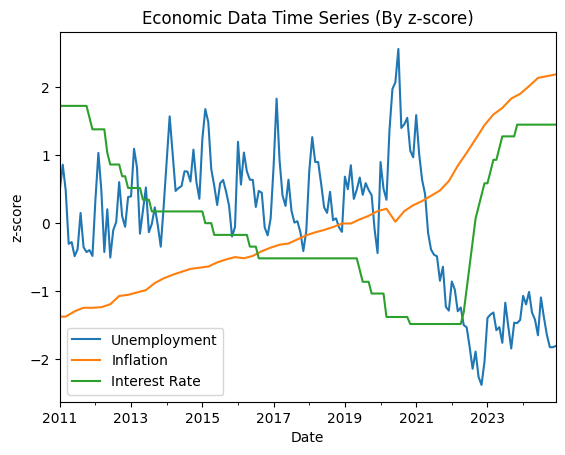

In [21]:
master_normal = (master_data - master_data.mean()) / master_data.std()
master_normal.plot(title="Economic Data Time Series (By z-score)")
plt.ylabel("z-score")
plt.show()

The rolling average of the data can also be visualised for better clarity of trends. 

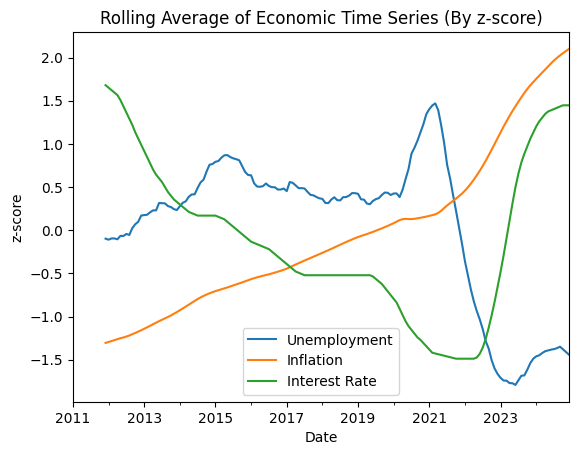

In [22]:
master_normal.rolling(window=12).mean().plot(title="Rolling Average of Economic Time Series (By z-score)")
plt.ylabel("z-score")
plt.show()

From the graph above, interest rates and unemployment seem to generally trend inversly. For example, in 2021 to 2023, unemployment rates dropped significantly. At roughly same time from 2022 to 2024, there was a surge in interest rates. In 2024, all three groups seem to be beginning to stablise. 


In [23]:
master_data.corr().style.background_gradient(cmap='YlOrRd')

,Unemployment,Inflation,Interest Rate
Unemployment,1.000000,-0.657557,-0.371986
Inflation,-0.657557,1.000000,0.013399
Interest Rate,-0.371986,0.013399,1.000000


The correlation map as depicted above most notebaly shows the negative correlation between unemployment and inflation at roughly -0.66. This means that there is a somewhat strong inverse relationship between the two groups. Unemployment and interest rate also show a slight inverse correlation at -0.37, while interest rate and inflation show almost no correlation. 

To conclude from the data, there is an inverse relationship between unemployment and inflation, a weak inverse relationship between inflation and unemployment and no relationship between interest rate and inflation.

## 3. STR Decomposition: Unemployment Time Series

### a) Split Data Into Training and Test Data

In [24]:
# Split train and test data set
train = unemployment_data.loc[:'2021-12-31']
test = unemployment_data.loc['2022-01-31':'2024-12-31']

### b) STR Decomposition

In [25]:
# find trend component
trend = train.rolling(window=12, center=True).mean()

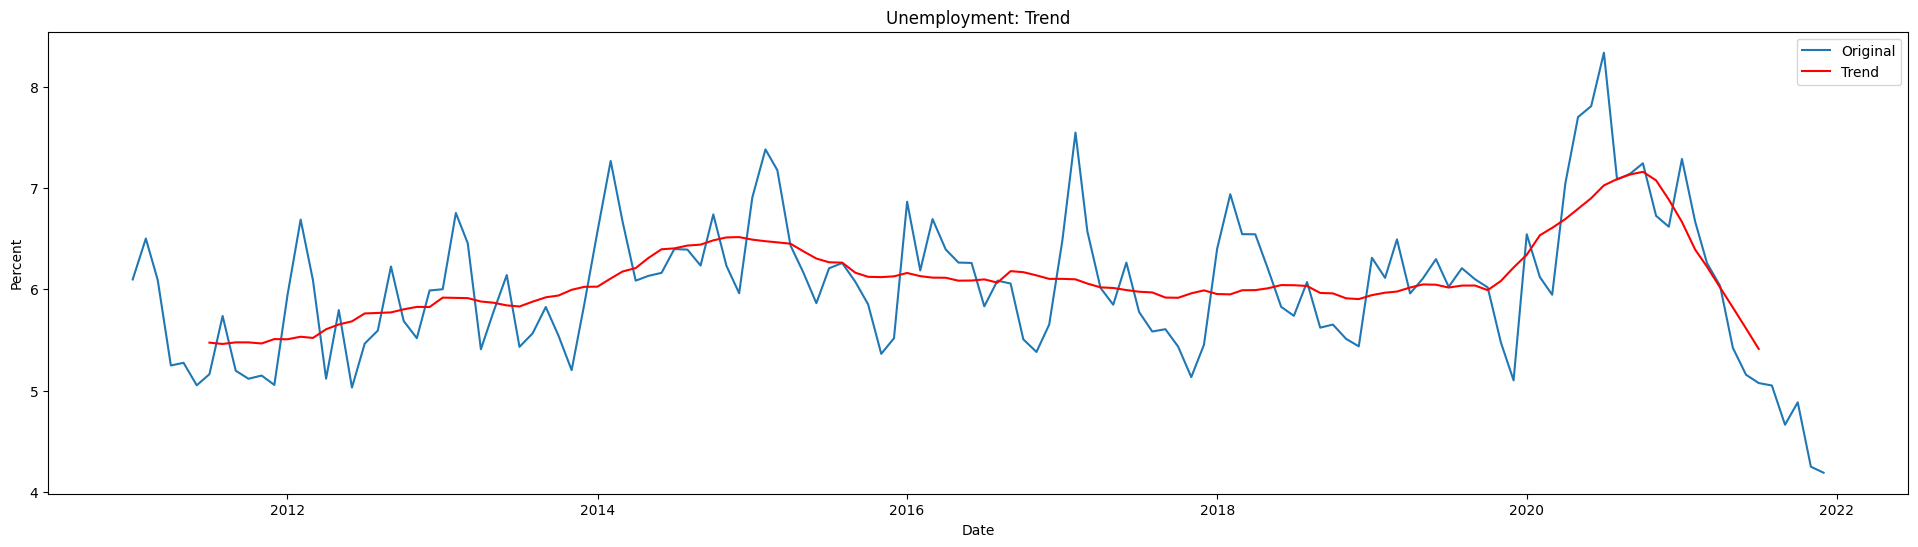

In [26]:
# Plot the trend component
plt.figure(figsize=(24,6))
plt.plot(train, label='Original')
plt.plot(trend, color='red', label='Trend')
plt.title("Unemployment: Trend")
plt.ylabel("Percent")
plt.xlabel("Date")
plt.legend()
plt.show()

In [27]:
raw_unemp_means = unemployment_data.groupby(unemployment_data.index.month).mean()
adjustment = raw_unemp_means.mean() 
unemp_means = raw_unemp_means - adjustment

In [28]:
# seasonal by definition
seasonal = train - trend

# Find mean 
seasonal = seasonal.groupby(seasonal.index.month).transform('mean')

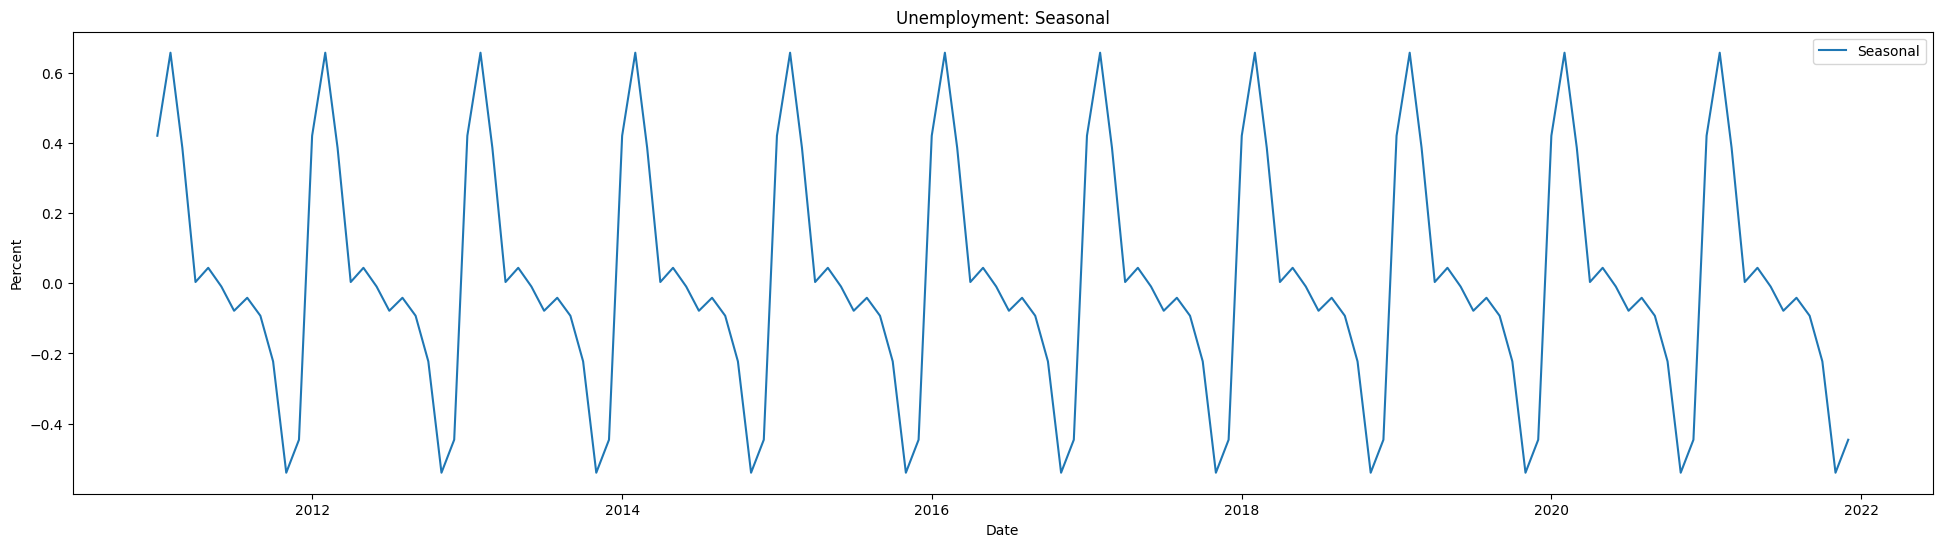

In [29]:
# Plot seasonal component
plt.figure(figsize=(24,6))
plt.plot(seasonal, label='Seasonal')
plt.title("Unemployment: Seasonal")
plt.ylabel("Percent")
plt.xlabel("Date")
plt.legend()
plt.show()

In [30]:
# Residual by defenition
residual = train - trend - seasonal

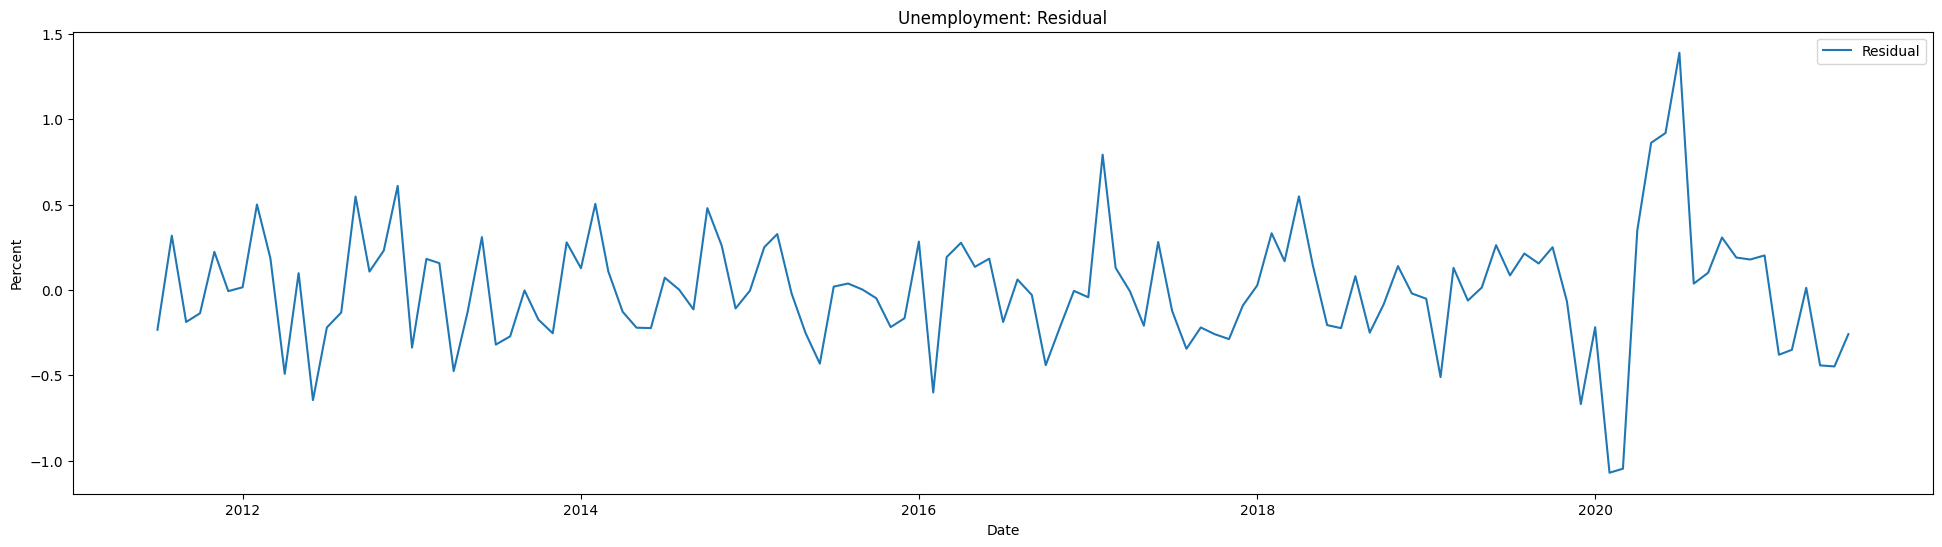

In [31]:
# Plot the residual component
plt.figure(figsize=(24,6))
plt.plot(residual, label='Residual')
plt.title("Unemployment: Residual")
plt.ylabel("Percent")
plt.xlabel("Date")
plt.legend()
plt.show()

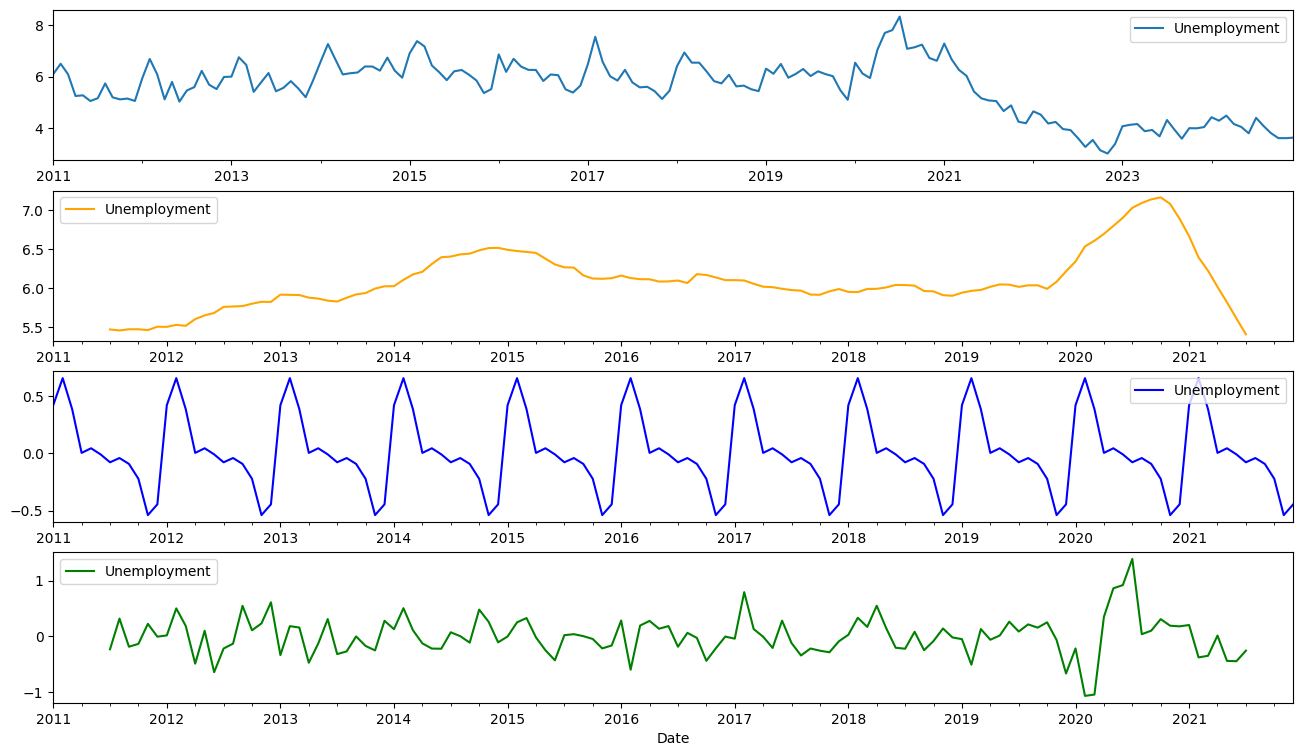

In [32]:
# Plot original, trend, seasonal and residual
fig, ax_str = plt.subplots(4)
unemployment_data.plot(label='Original', ax=ax_str[0])
trend.plot(color='orange', label='Trend', ax=ax_str[1])
seasonal.plot(color='blue', label='Seasonal', ax=ax_str[2])
residual.plot(color='green', label='Residual', ax=ax_str[3])
fig.set_size_inches((16, 9))
plt.legend()
plt.show()

## 4. Timeseries Models

### a) Fit ARIMA Model

In [33]:
%pip install -U statsmodels==0.14.4 scipy==1.14.1


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /opt/jupyter/bin/python3.12 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

<Axes: xlabel='Date'>

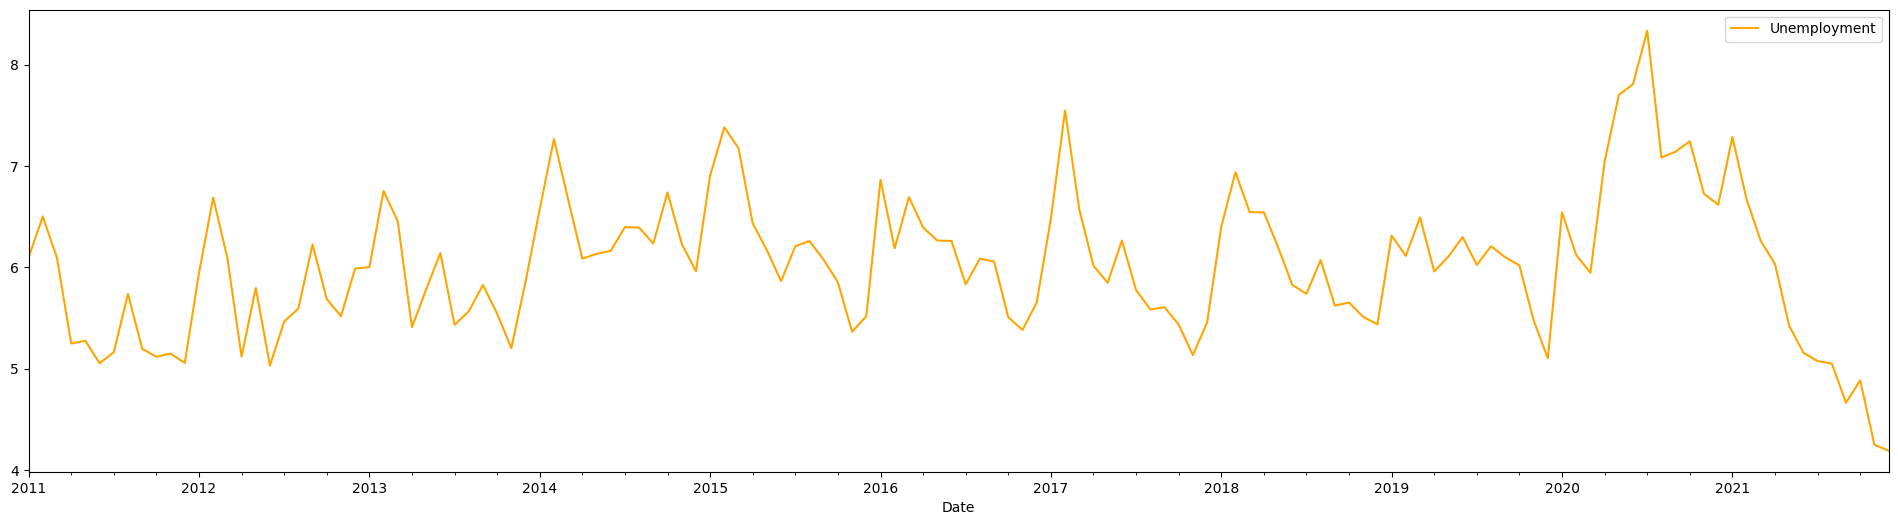

In [35]:
# Check if stationary 
train.plot(color='orange', figsize=(24,6))

<Axes: xlabel='Date'>

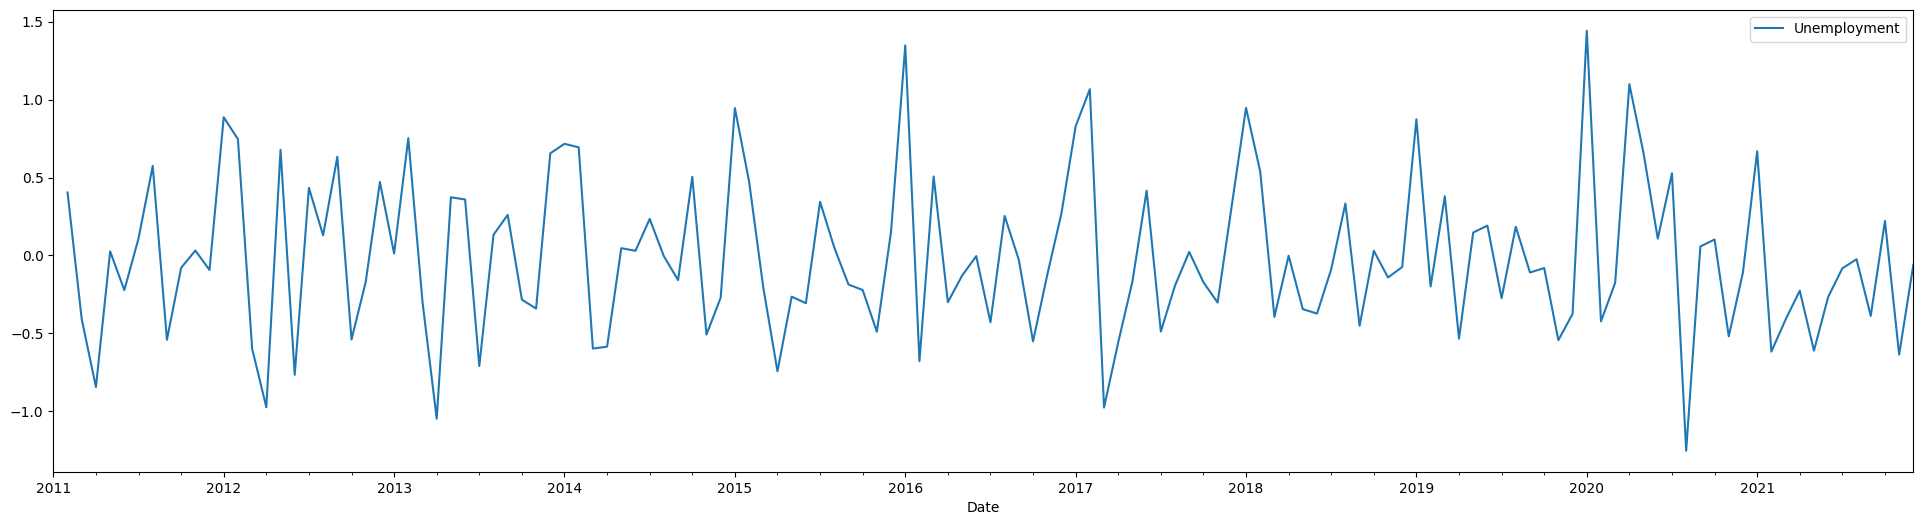

In [36]:
trend_d1 = train.diff()
trend_d1.plot(figsize=(24,6))

<Axes: xlabel='Date'>

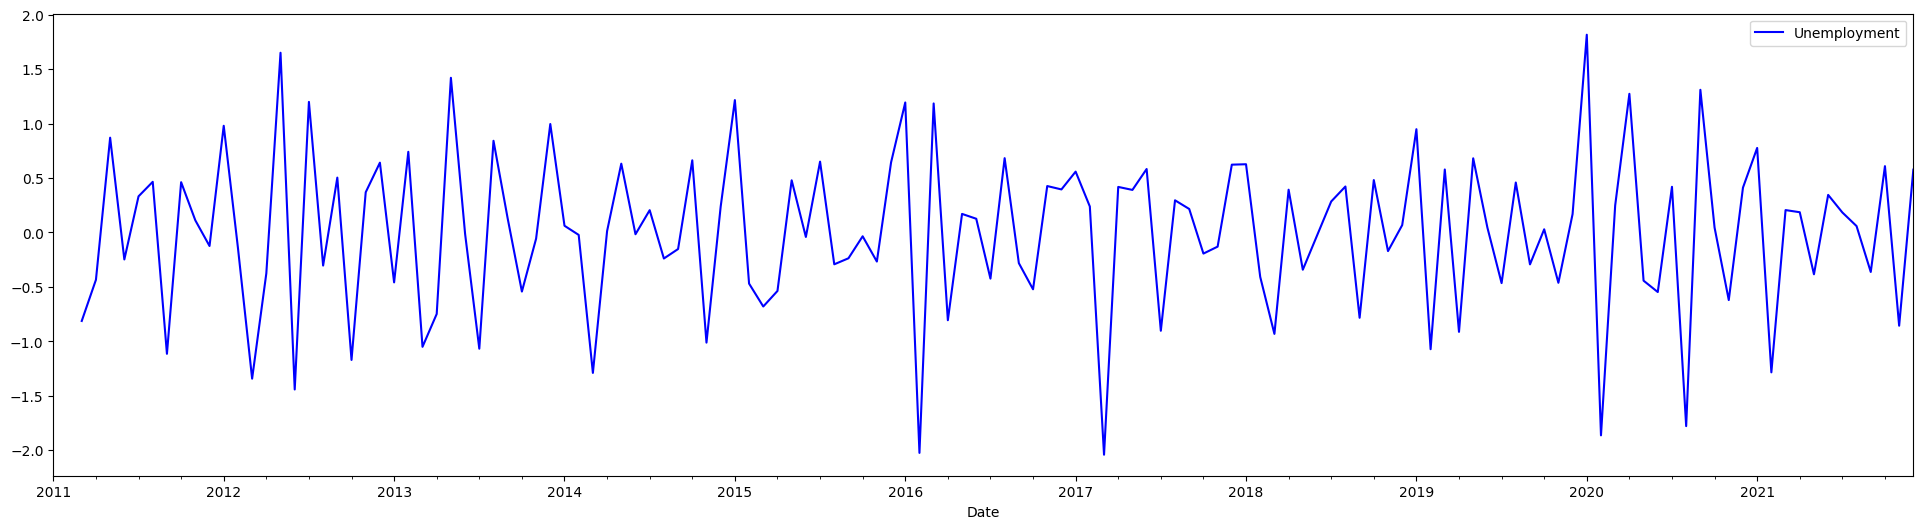

In [37]:
trend_d2 = trend_d1.diff()
trend_d2.plot(figsize=(24,6),color='blue',)

In [38]:
# make sure it is 1D without Nans
series = pd.Series(trend_d2.squeeze(), dtype="float64").dropna()

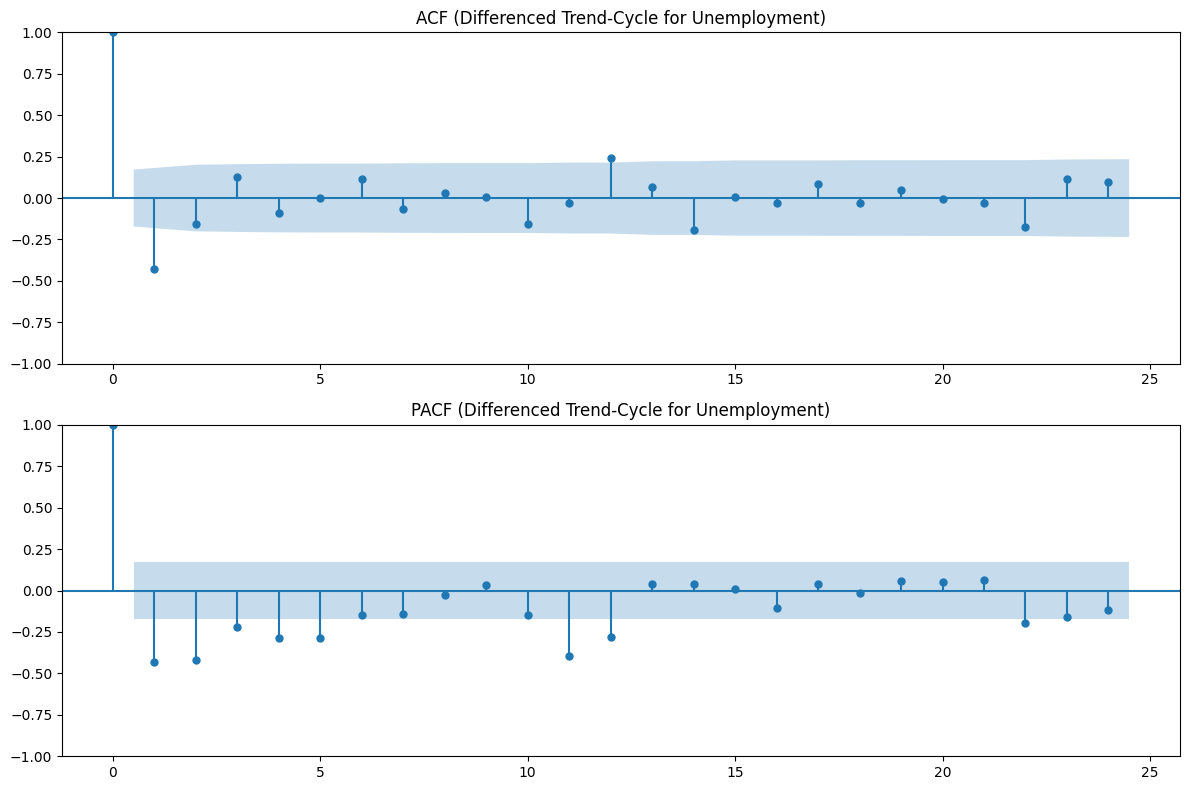

In [39]:
# Plot ACF and PACF to see if data is stationary 
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(series, lags=24, ax=axes[0], fft=True, missing="drop")
axes[0].set_title("ACF (Differenced Trend-Cycle for Unemployment)")
plot_pacf(series, lags=24, ax=axes[1], method="ywm")
axes[1].set_title("PACF (Differenced Trend-Cycle for Unemployment)")
plt.tight_layout()
plt.show()

The best ARIMA fit was tested by finding the combination with the lowest AIC and BIC. This resulted in an ARIMA with an order (1, 2, 2)

In [162]:
arima_1_2_2 = ARIMA(trend, order=(1, 2, 2)).fit()
print(arima_1_2_2.summary())

                               SARIMAX Results                                
Dep. Variable:                  trend   No. Observations:                  168
Model:                 ARIMA(1, 2, 2)   Log Likelihood                 731.034
Date:                Fri, 31 Oct 2025   AIC                          -1454.069
Time:                        06:54:57   BIC                          -1441.621
Sample:                    01-01-2011   HQIC                         -1449.016
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8352      0.044     18.881      0.000       0.749       0.922
ma.L1          0.6250      0.063      9.993      0.000       0.502       0.748
ma.L2          0.5001      0.060      8.377      0.0

/opt/jupyter/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/jupyter/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/jupyter/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


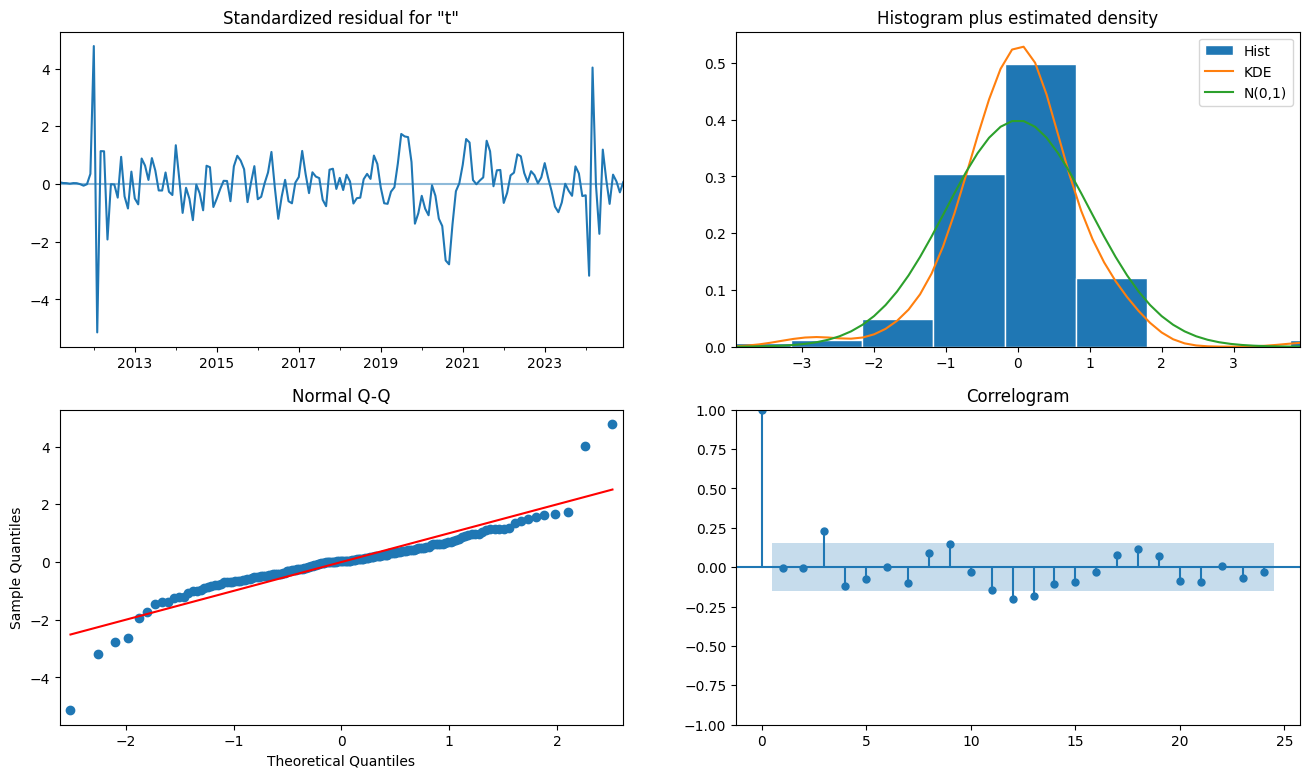

In [164]:
fig = plt.figure(figsize=(16, 9))
fig = arima_1_2_2.plot_diagnostics(fig=fig, lags=24)

### b) Forecast

In [43]:
import numpy as np

Using the STR components, forecasting can be conducted.

In [44]:
# forecast using the trend component
arima_fcst = arima_1_2_2.get_forecast(steps=24)
arima_predictions = pd.DataFrame(arima_fcst.predicted_mean)
arima_predictions.rename(columns={"predicted_mean": "trend"}, inplace=True)

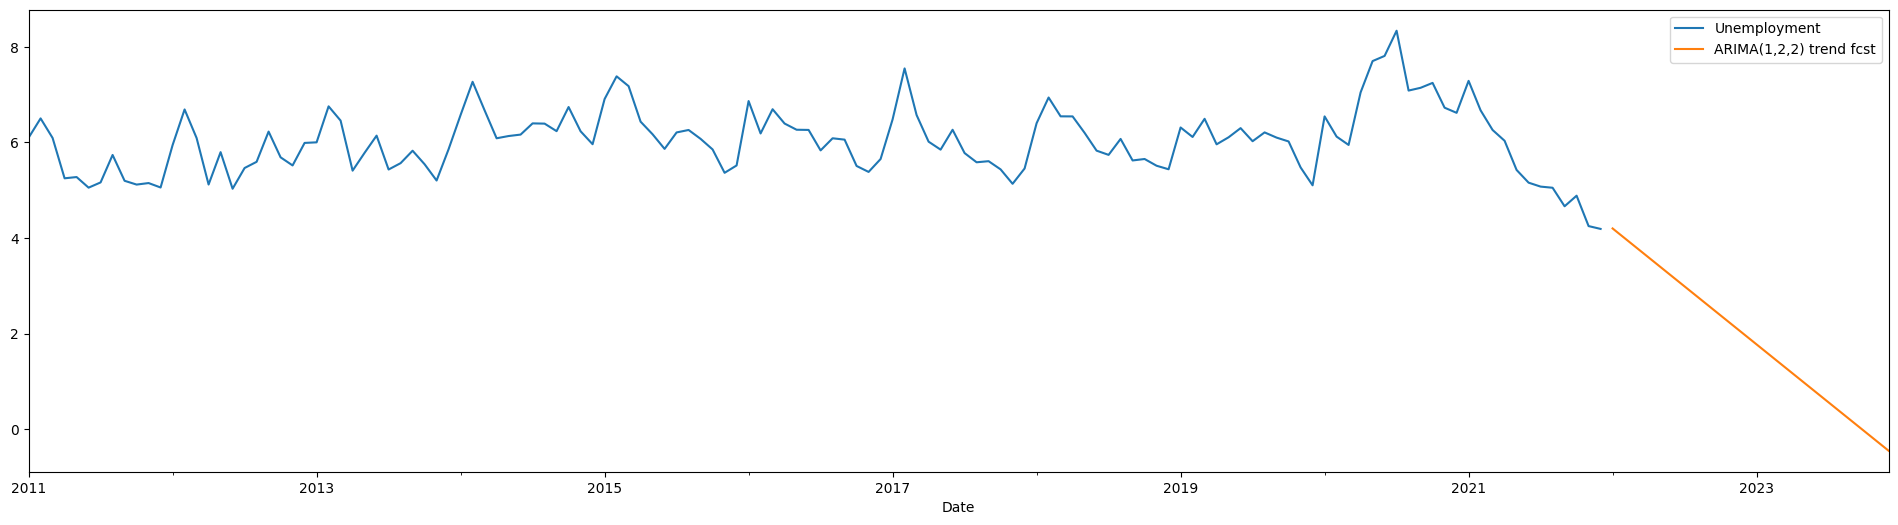

In [45]:
# plot forecast
fig, ax_arima_fcst = plt.subplots(figsize=(24,6))
train.plot(label='Original', ax=ax_arima_fcst)
arima_predictions['trend'].plot(label="ARIMA(1,2,2) trend fcst", ax=ax_arima_fcst)
plt.legend()

From observing the trend, it can be concluded the ARIMA has predicted a downwards forcast. In the next graph, the seasonal component will be added.

In [46]:
# Add seasonal component based on the month index
unemp_means = pd.Series(unemp_means.squeeze(), dtype="float64").dropna()
arima_predictions['month'] = arima_predictions.index.month
arima_predictions['seasonal'] = arima_predictions['month'].map(unemp_means)
arima_predictions.head()

,trend,month,seasonal
2022-01-01,4.198327,1,0.461219
2022-02-01,3.996144,2,0.643600
2022-03-01,3.793918,3,0.408648
2022-04-01,3.591716,4,0.033120
2022-05-01,3.389500,5,0.038009


In [47]:
# add trend and seasonal 
arima_predictions['trend+seasonal'] = arima_predictions['trend'] + arima_predictions['seasonal']
arima_predictions.head()

,trend,month,seasonal,trend+seasonal
2022-01-01,4.198327,1,0.461219,4.659545
2022-02-01,3.996144,2,0.643600,4.639745
2022-03-01,3.793918,3,0.408648,4.202566
2022-04-01,3.591716,4,0.033120,3.624836
2022-05-01,3.389500,5,0.038009,3.427509


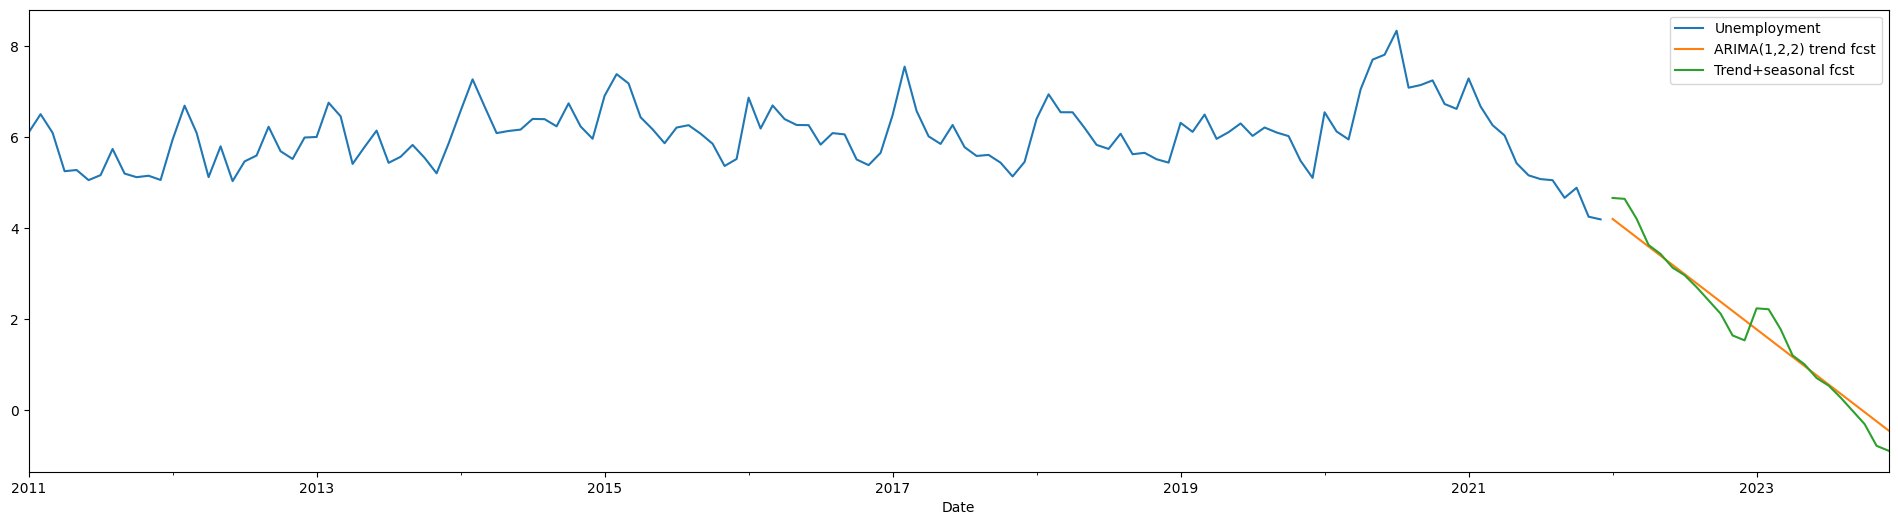

In [48]:
# plot trend+seasonal forecast
fig, ax_arima_fcst = plt.subplots(figsize=(24,6))
train.plot(label='Original', ax=ax_arima_fcst)
arima_predictions['trend'].plot(label="ARIMA(1,2,2) trend fcst", ax=ax_arima_fcst)
arima_predictions['trend+seasonal'].plot(label="Trend+seasonal fcst", ax=ax_arima_fcst)
plt.legend()

From observing the trend+seasonal plot, we can observe the downward trend, as well as a slight rise in unemployment in the begginning of 2023. In the next graph, it depicts a forecast with a 95% interval.

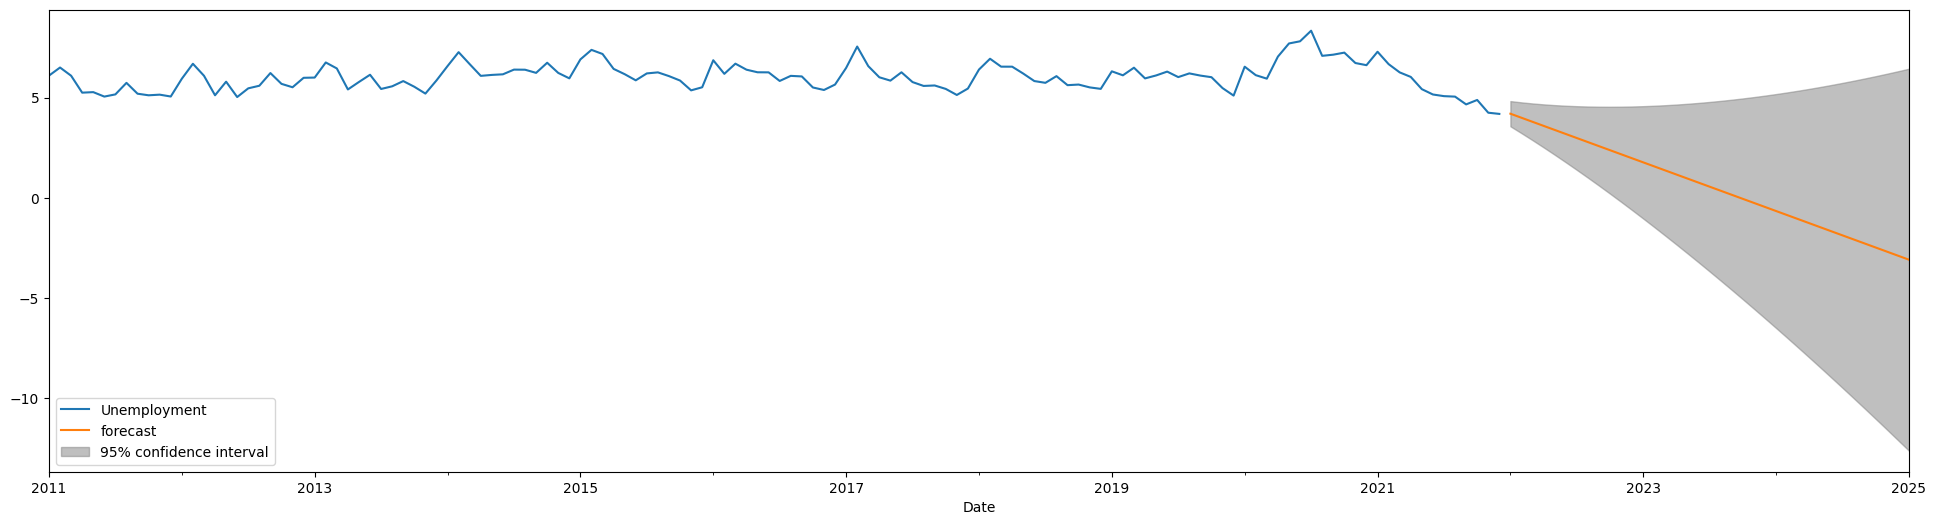

In [49]:
# Plot forecast with 95% confidence interval
fig, ax_arima_fcst = plt.subplots(figsize=(24,6))
train.plot(label='Original', ax=ax_arima_fcst)
fig = plot_predict(arima_1_2_2,
                   start=pd.to_datetime("2022-01-01"), 
                   end=pd.to_datetime("2024-12-31"), 
                   ax=ax_arima_fcst)

## 5. Pure forecasters: Neural Network Based Methods 

### a) Choose Neural Network Method
Long Short Term Memory (LSTM) will be used as a Neural Network Method. LSTM is good for storing long term memory, removing unnecessary data, and predicting sequences. In this data set, the unemployment trends are temporal sequences and are have large dependencies on past data. 

### b) Conduct Nerual Network Test

In [50]:
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

2025-10-31 05:56:46.649420: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-31 05:56:46.661957: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761890206.673436  411020 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761890206.678264  411020 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761890206.693542  411020 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [165]:
# Create Scale
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

# Create lagged sequence to predict the next month
def create_supervised(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window, 0])
        y.append(data[i+window, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_supervised(train_scaled, window=12)
X_test, y_test = create_supervised(test_scaled, window=12)

In [113]:
def slff_relu(input_dim, hidden_1_dim=64):
        # Single-layer FF network with Rectified linear unit (relu) activation fxn
    inputs = keras.layers.Input(shape=(input_dim,))
    hidden_layer_1 = keras.layers.Dense(hidden_1_dim, activation='relu')(inputs)
    outputs = keras.layers.Dense(1, activation='tanh')(hidden_layer_1)
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [114]:
# Create network with three layers 
def deepff(input_dim, hidden_1_dim=64, hidden_2_dim=32, hidden_3_dim=32):
    inputs = keras.layers.Input(shape=(input_dim,))
    hidden_layer_1 = keras.layers.Dense(hidden_1_dim, activation='relu')(inputs)
    hidden_layer_2 = keras.layers.Dense(hidden_2_dim, activation='relu')(hidden_layer_1)
    hidden_layer_3 = keras.layers.Dense(hidden_3_dim, activation='relu')(hidden_layer_2)
    outputs = keras.layers.Dense(1, activation='tanh')(hidden_layer_3)
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [168]:
# typeout block below to prevent retraining, 12 lagged variables
model = deepff(input_dim=12)
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,001 (15.63 KB)

 Trainable params: 4,001 (15.63 KB)

 Non-trainable params: 0 (0.00 B)

In [170]:
# train 10 epochs (small size for time efficiency, for demonstration purposes)
model.fit(X_train, y_train, epochs=10, batch_size=8, verbose=1)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0323 
Epoch 2/10


W0000 00:00:1761895001.645225  411020 op_level_cost_estimator.cc:743] Invalid device specifications for CPU: type: "CPU" vendor: "AuthenticAMD" model: "241" num_cores: 256 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 32768 l2_cache_size: 1048576 l3_cache_size: 134217728 memory_size: 268435456


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0267  
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0217 
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0212  
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0162 
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0163  
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0185  
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0180  
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0168 
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0161  


In [171]:
# generate one step prediction
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


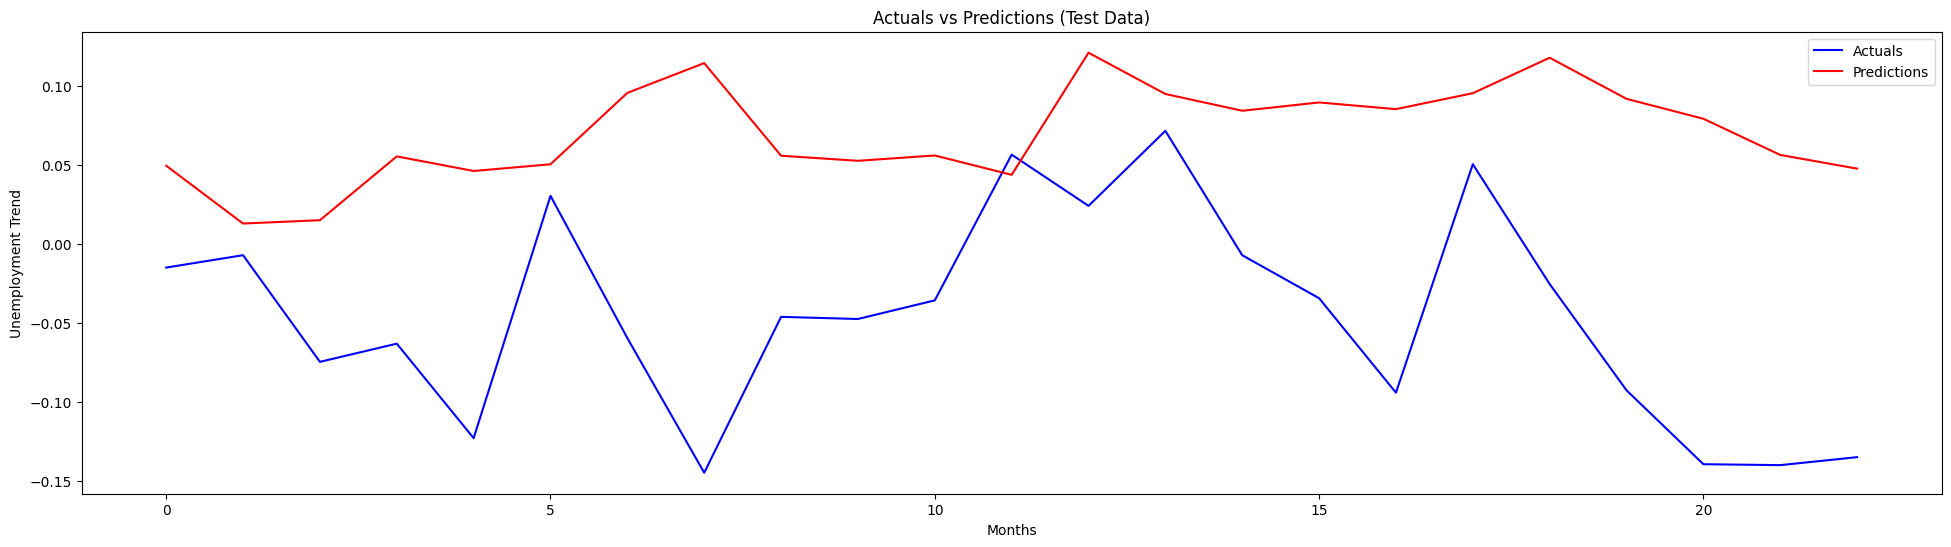

In [172]:
# Plot test data predictions
def plot_pred(y_test, y_pred, period=35):
    plt.figure(figsize=(24,6))
    plt.plot(y_test[-period:], "b", label="Actuals")
    plt.plot(y_pred[-period:], "r", label="Predictions")
    plt.title("Actuals vs Predictions (Test Data)")
    plt.xlabel("Months")
    plt.ylabel("Unemployment Trend")
    plt.legend()
    plt.show()

plot_pred(y_test, y_pred)

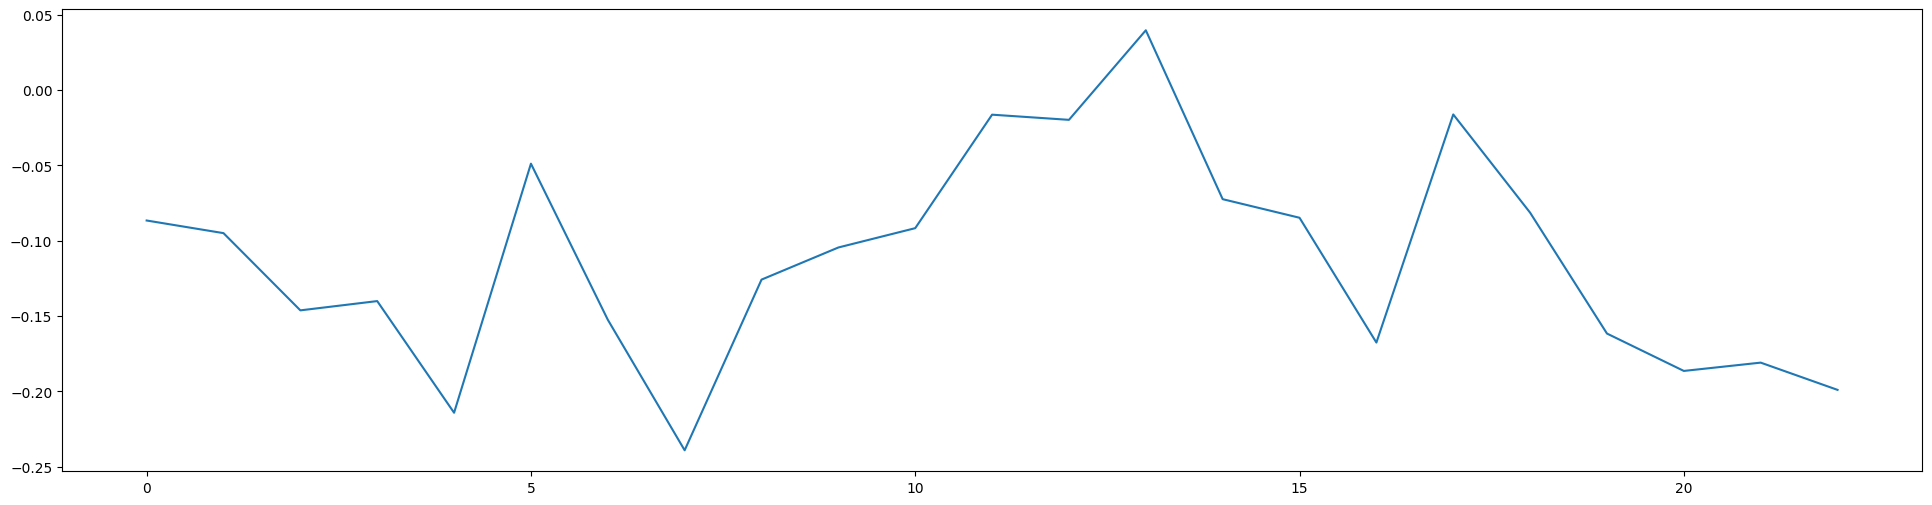

In [120]:
# Compute and plot the test data errors
errors = np.squeeze(y_test) - np.squeeze(y_pred)
plt.figure(figsize=(24,6))
plt.plot(errors)

From the graph, it can be deduced that the predictions are not accurate, producing many errors. 

In [173]:
def multistep_prediction(H, model, X_pred,residuals=[]):
    # Initialise lists for storing multi-step predictions
    y_pred_multi = []
    X_pred_multi = []

    for t in range(H):
        # get next prediction
        X_pred = np.array(X_pred.reshape(1,len(X_pred)))
        new_y= float(model.predict(X_pred))
    
        # update 
        y_pred_multi.append(float(new_y))
        X_pred_multi.append(list(X_pred[0])) 
    
        # prepare net input with bootstrapped training residuals
        X_pred = X_pred_multi[t][:-1]
        if len(residuals) == 0:
            X_pred.insert(0,new_y)
        else:
            X_pred.insert(0,(new_y+np.random.choice(residuals)))
        X_pred = np.array(X_pred)

    return y_pred_multi, X_pred_multi

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step

/tmp/ipykernel_411020/2031136396.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_y= float(model.predict(X_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


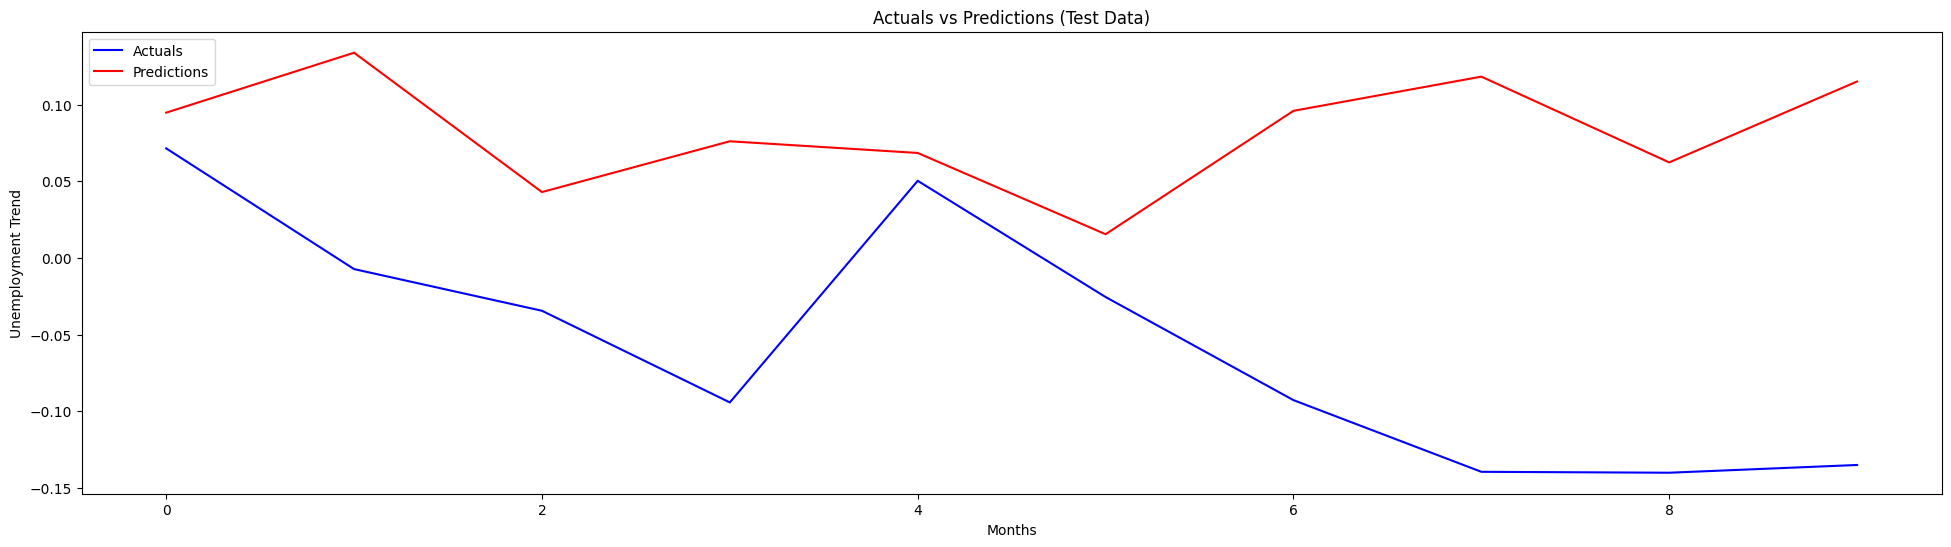

In [174]:
# Prediction horizon, next 10 months 
H = 10

X_test_multi = X_test[-H:,:]
y_test_multi = y_test[-H:]

# Prepare first input to multistep prediction loop
X_pred = X_test_multi[0,:]

# Multistep prediction
y_pred_multi, X_pred_multi = multistep_prediction(H,model,X_pred)
plot_pred(y_test_multi, y_pred_multi)

In [177]:
# Bootstrap iterations
K = 5 # for efficiency, demonstration purposes, should be 100

# Prepare first input to multistep bootsrtap loop
X_pred = X_test_multi[0,:]
y_pred_bootstrap = []

# Use multistep prediction to generate bootstrap data, 
# List of training residuals to sample from passed in as fourth argument 

for k in range(K):
    y_pred_multi, X_pred_multi = multistep_prediction(H,model,X_pred,residuals)
    y_pred_bootstrap.append(y_pred_multi)
    # store y predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step

/tmp/ipykernel_411020/2031136396.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_y= float(model.predict(X_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

W0000 00:00:1761895364.745907  411020 op_level_cost_estimator.cc:743] Invalid device specifications for CPU: type: "CPU" vendor: "AuthenticAMD" model: "241" num_cores: 256 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 32768 l2_cache_size: 1048576 l3_cache_size: 134217728 memory_size: 268435456


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


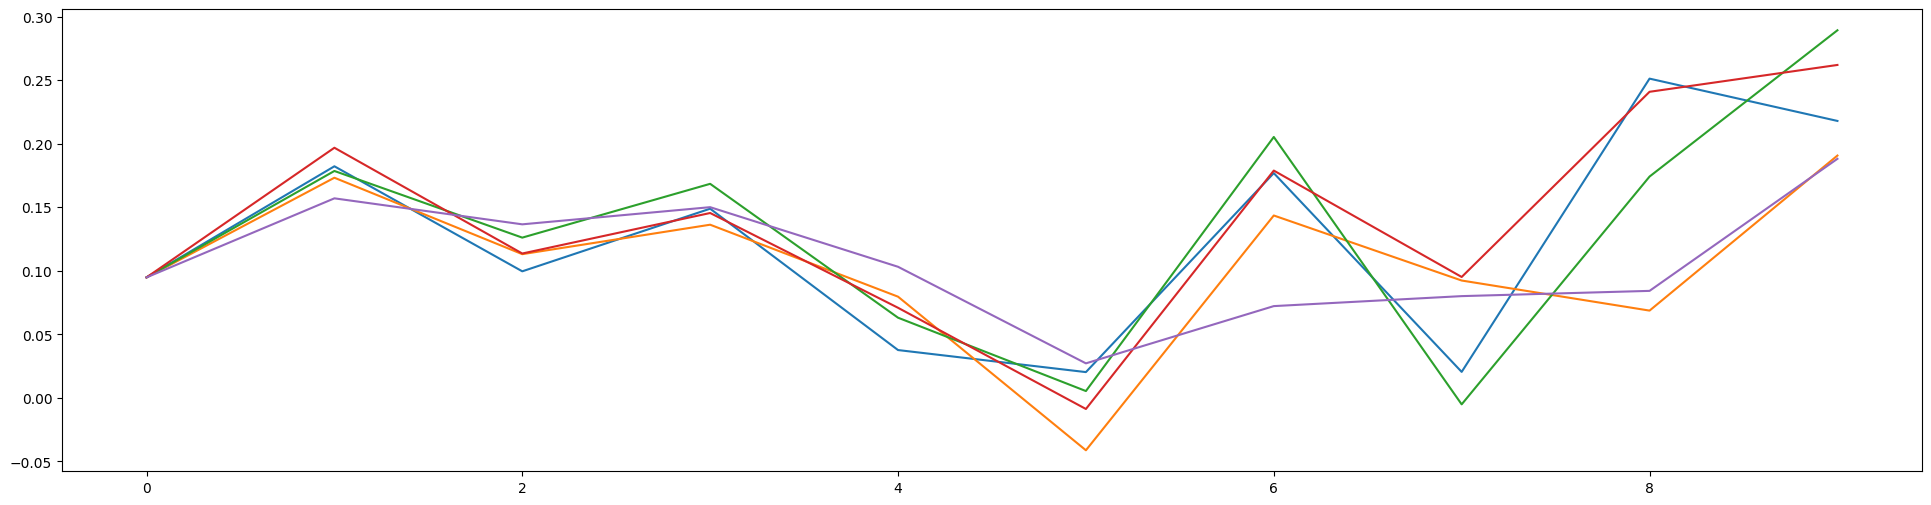

In [178]:
# Useful utility method for transposing lists of lists    
def transposed_2d_list(l):
    return [[row[i] for row in l] for i in range(len(l[0]))]    

plt.figure(figsize=(24,6))
plt.plot(transposed_2d_list(y_pred_bootstrap[-5:]))

In [179]:
bootstrap_predictions = pd.DataFrame(index = unemployment_data.index.values[-H:])

for pctl in range(0,101,10):
    bootstrap_predictions[str(pctl)] = np.percentile(y_pred_bootstrap,pctl,axis=0)

bootstrap_predictions.rename(columns={'50': "median"}, inplace=True)
bootstrap_predictions['actuals'] = y_test[-H:]

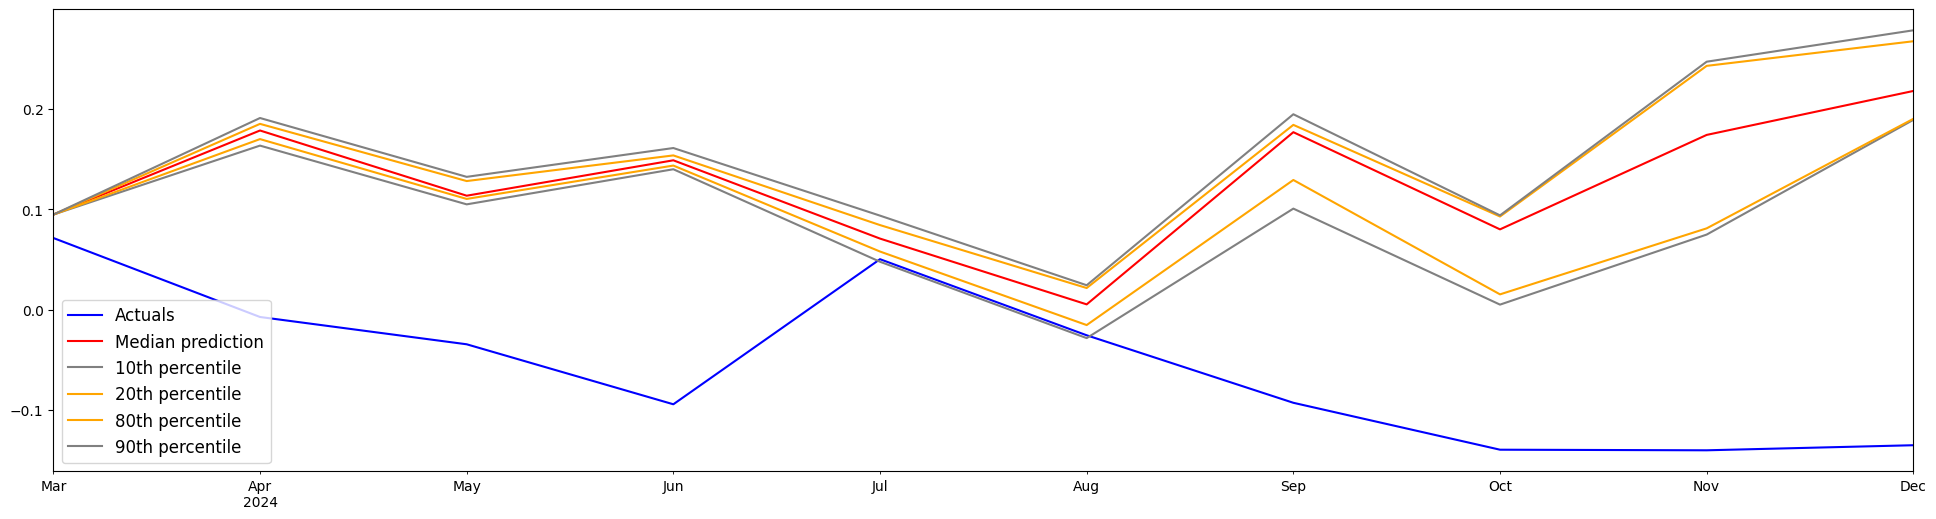

In [180]:
plt.figure(figsize=(24,6))
bootstrap_predictions['actuals'].plot(color = 'blue', label='Actuals')
bootstrap_predictions['median'].plot(color = 'red',label = 'Median prediction' )
bootstrap_predictions['10'].plot(color = 'grey',label = '10th percentile')
bootstrap_predictions['20'].plot(color = 'orange',label = '20th percentile' )
bootstrap_predictions['80'].plot(color = 'orange',label = '80th percentile' )
bootstrap_predictions['90'].plot(color = 'grey',label = '90th percentile')
plt.legend(loc = 'lower left', fontsize = 12)

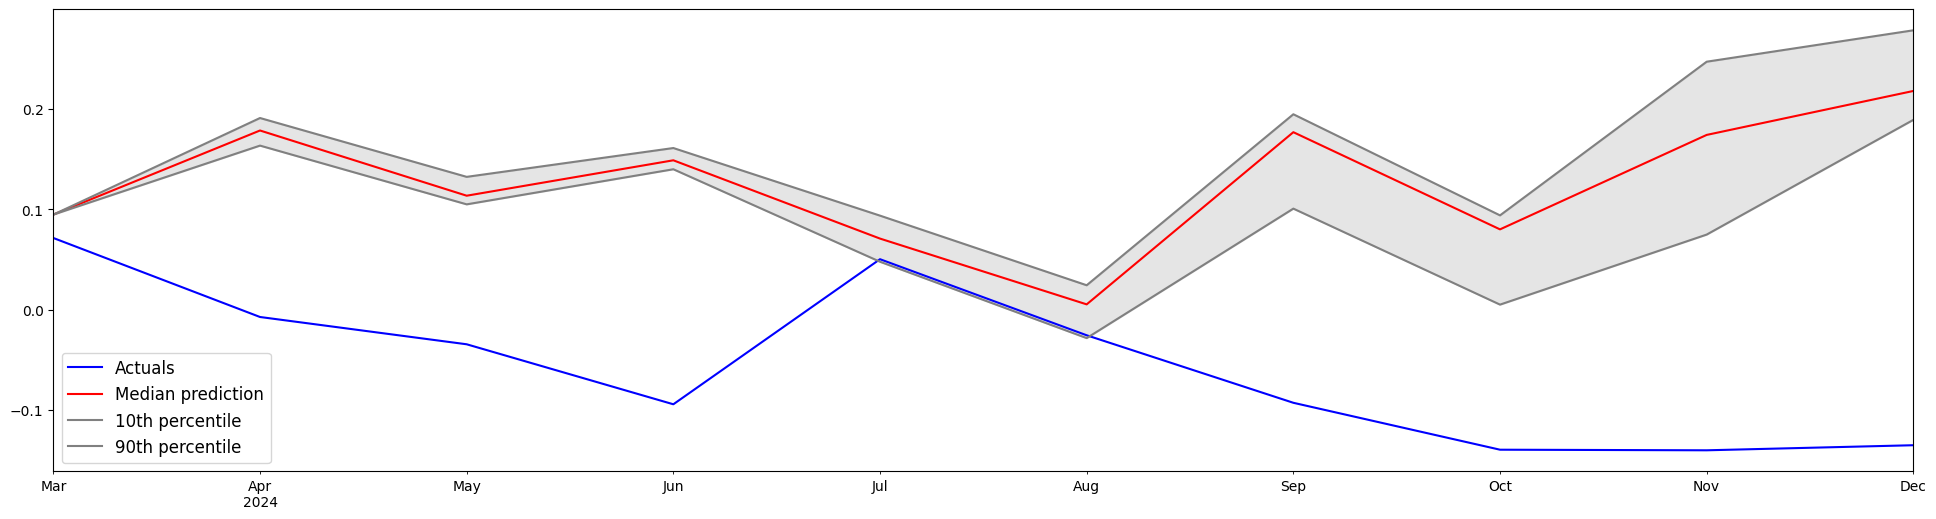

In [181]:
# plot interval with fill
plt.figure(figsize=(24,6))
bootstrap_predictions['actuals'].plot(color = 'blue', label='Actuals')
bootstrap_predictions['median'].plot(color = 'red',label = 'Median prediction')
bootstrap_predictions['10'].plot(color = 'grey', label = '10th percentile' )
bootstrap_predictions['90'].plot(color = 'grey', label = '90th percentile')
plt.legend(loc = 'lower left', fontsize = 12)

x = unemployment_data.index.values[-H:]
plt.fill_between(x, bootstrap_predictions['10'], bootstrap_predictions['90'], color='grey', alpha=0.2)

In the interval forecasts above, it can be seen that the neural network did not predict the data well. Instead, the prediction was seen to be significantly higher than the actual unemployment rates. This is because as seen in the PCA analysis, 2022 experienced a large drop in unemployment rates due to external factors, devieating from it's past trends. This creates difficulty for a model to predict using past data. Below shows the comparison of the actual data versus predicted data.

In [139]:
# Split test data again into train and test
trend_train = trend.loc[:'2021-12-31']
trend_test = trend.loc['2022-01-01':]

In [182]:
# predict forecast using test data
predictions = []
last_window = train_scaled[-12:] 

for i in range(len(trend_test)):
    pred = model.predict(last_window.reshape(1, -1), verbose=0)
    predictions.append(pred[0][0])
    last_window = np.append(last_window[1:], pred)

trend_forecast = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

W0000 00:00:1761895825.451528  411020 op_level_cost_estimator.cc:743] Invalid device specifications for CPU: type: "CPU" vendor: "AuthenticAMD" model: "241" num_cores: 256 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 32768 l2_cache_size: 1048576 l3_cache_size: 134217728 memory_size: 268435456


In [184]:
# flatten to proportion
seasonal_test = seasonal.loc[trend_test.index]
forecast_final = trend_forecast.flatten() + seasonal_test.values

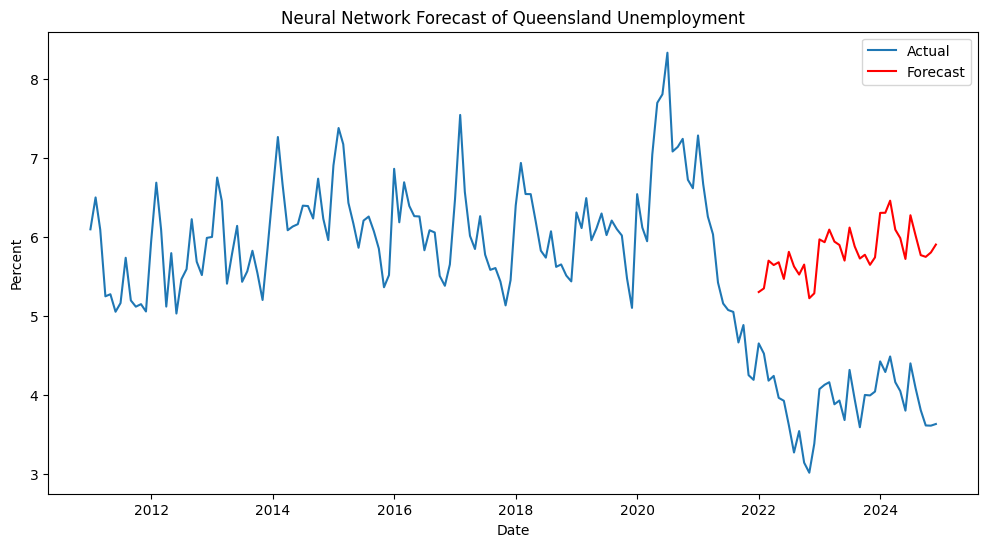

In [188]:
# plot figure
plt.figure(figsize=(12,6))
plt.plot(unemployment_data, label="Actual")
plt.plot(trend_test.index, forecast_final, label="Forecast", color="red")
plt.title("Neural Network Forecast of Queensland Unemployment")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.legend()
plt.show()

As seen in the plot above, the forecasted data is significantly higher than the actual data. We can conclude that although economic factors generally follow a certain pattern, it can also be heavly influenced by global events and factors. Thus we should not heavily rely on forecasting as unexpected events are frequently present in the economy. Instead we should use forecasting as a reference.

## 6. Using side data: Affect on Interest Rates Using Side Data

### a) Interest Rate Data 

In [213]:
import sklearn.metrics as skm

In [214]:

# Mean absolute difference between scenarios
mae_diff = skm.mean_absolute_error(forecast2_full, forecast1_full)

# Mean squared difference
mse_diff = skm.mean_squared_error(forecast2_full, forecast1_full)

# Maximum difference
max_diff = np.max(forecast1_full - forecast2_full)


NameError: name 'y_test_future' is not defined

In [205]:
# Last observed interest rate (Dec 2024)
last_rate = interest_rates_data.loc['2024-12-31']

In [209]:
# Define six months beyond test data
future_months = pd.date_range(start='2024-01-31', periods=6, freq='ME')  # Monthly Start frequency

# Scenario 1: reduction by 0.75%
rate_drop = last_rate - 0.75
series_1 = pd.Series(rate_drop, index=future_months, name="Interest Rate")

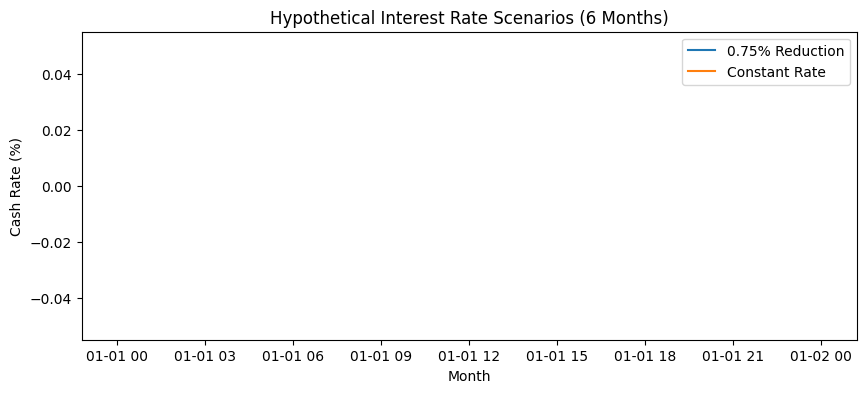

In [211]:
plt.figure(figsize=(10,4))
plt.plot(series_1, label="0.75% Reduction")
plt.plot(series_2, label="Constant Rate")
plt.title("Hypothetical Interest Rate Scenarios (6 Months)")
plt.xlabel("Month")
plt.ylabel("Cash Rate (%)")
plt.legend()
plt.show()